# 2aii. BOLD Timeseries Comparison: Atlas-Based vs. Subject-Specific Habenula ROIs

Per Angie's requested reorg: before comparing whole-brain connectivity maps, check whether
the manual and atlas-based habenula ROIs are capturing the same underlying BOLD signal in
the first place. Two questions:

1. **tSNR comparison** - is signal quality (temporal SNR) within each ROI type comparable?
2. **Timeseries correlation** - for each participant, how correlated is their averaged BOLD
   timeseries when extracted from the manual ROI vs. the atlas ROI?

This notebook loads the results computed on the HPC cluster (`roi-bold-comp.py`, run via
`run_roi-bold-comp.sbatch` across the full N=1,479 sample, then combined with
`merge-bold-comp-results.py`) and reports summary statistics + plots for both questions.

For provenance: tSNR was computed from each subject's minimally-preprocessed (pre-denoising)
BOLD, cropped to a small bounding box around the ROIs to keep memory use low. The timeseries
correlation was computed on the same denoised, averaged timeseries that feed the connectivity
GLM (already extracted via `3dmaskave` for both ROI types).

In [7]:
import os.path as op

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, wilcoxon
from scipy.stats import t as t_dist


## 1. Load Results

Same sample as `2ai-roi-comparison.ipynb` (N=1,479 - the 3 mismatched subjects already
excluded on the cluster side via `EXCLUDED_SUBJECTS` in `roi-bold-comp.py`).

In [8]:
data_dir = "./dset"
deriv_dir = op.join(data_dir, "derivatives")
roi_analysis_dir = op.join(deriv_dir, "roi-analysis")

results_fn = op.join(roi_analysis_dir, "bold_comparison_results_merged.tsv")
df = pd.read_csv(results_fn, sep="\t")

print(f"Loaded {len(df)} subjects from: {results_fn}")
df.head()


Loaded 1480 subjects from: ./dset/derivatives/roi-analysis/bold_comparison_results_merged.tsv


,subject_id,n_timepoints,pearson_r,p_value,manual_tsnr,atlas_tsnr,manual_n_voxels,atlas_n_voxels,error
0,sub-0050004,160,0.765618,4.414229e-32,61.051731,46.406033,8,69,NaN
1,sub-0050005,165,0.818998,3.615605e-41,42.152496,31.543097,18,69,NaN
2,sub-0050006,168,0.868702,1.602286e-52,57.511753,51.452148,14,69,NaN
3,sub-0050007,137,0.840304,1.029671e-37,34.130531,24.726254,12,69,NaN
4,sub-0050008,125,0.927299,2.497621e-54,41.715107,38.752872,10,69,NaN


## 2. Data Quality Check

Flag any subjects with missing values before computing summary stats, rather than silently
dropping them. (`sub-0050353` is expected here - see the note below.)

In [9]:
print("Missing values per column:")
print(df.isna().sum())

missing_corr = df[df["pearson_r"].isna()]
if len(missing_corr) > 0:
    print(f"\n{len(missing_corr)} subject(s) missing a timeseries correlation:")
    print(missing_corr[["subject_id", "manual_tsnr", "atlas_tsnr"]].to_string(index=False))
    print(
        "\nsub-0050353's manual-ROI averaged timeseries file was empty (0 valid timepoints) "
        "when extracted via 3dmaskave - almost certainly because its manual habenula ROI has "
        "zero overlapping voxels once resampled onto the functional grid. This is the same "
        "subject that's missing from the current group-drawn model table used for the main "
        "connectivity GLM (see habenula_sample_exclusions memory) - consistent with a genuine "
        "data problem for this subject rather than a pipeline bug. tSNR still computed fine for "
        "them since that doesn't depend on the timeseries file, so they're kept in the tSNR "
        "analysis below and only dropped from the correlation analysis."
    )

# Detect corrupted rows: a p_value outside [0, 1] means the columns are misaligned for that
# row (most likely a missing tab between two fields in that subject's per-subject file,
# possibly from two overlapping job runs writing to it near-simultaneously - to_csv isn't an
# atomic write). Every field for a corrupted row is unreliable, not just p_value, so drop the
# whole row rather than trying to patch it here.
def _invalid_pvalue(v):
    return pd.notna(v) and not (0 <= v <= 1)

corrupted = df[df["p_value"].apply(_invalid_pvalue)]
if len(corrupted) > 0:
    print(f"\n{len(corrupted)} subject(s) with a corrupted row (p_value outside [0, 1]):")
    print(corrupted.to_string(index=False))
    print(
        "\nDropping these from the analysis below - the underlying per-subject file(s) on the "
        "cluster should be deleted and re-run, then re-merged, rather than trusting these rows."
    )
    df = df[~df["p_value"].apply(_invalid_pvalue)].reset_index(drop=True)
    print(f"\nN after dropping corrupted rows: {len(df)}")


Missing values per column:
subject_id            0
n_timepoints          0
pearson_r             0
p_value               0
manual_tsnr           0
atlas_tsnr            0
manual_n_voxels       0
atlas_n_voxels        0
error              1480
dtype: int64


## 3. tSNR Comparison

Mean tSNR within each ROI type, computed per subject from the minimally-preprocessed BOLD.
A paired test is appropriate here since it's the same subject/scan measured twice (once per
ROI method).

In [10]:
print(f"{'='*60}")
print(f"tSNR SUMMARY (N = {len(df)})")
print(f"{'='*60}")

for col, label in [("manual_tsnr", "Manual ROI"), ("atlas_tsnr", "Atlas ROI")]:
    print(f"\n{label} tSNR:")
    print(f"  Mean:   {df[col].mean():.2f}")
    print(f"  Median: {df[col].median():.2f}")
    print(f"  Range:  [{df[col].min():.2f}, {df[col].max():.2f}]")

tsnr_diff = df["manual_tsnr"] - df["atlas_tsnr"]
print(f"\nMean difference (manual - atlas): {tsnr_diff.mean():.2f} (SD = {tsnr_diff.std():.2f})")

# Percent difference, computed per subject (manual vs. its own atlas value) then summarized -
# more informative than a single group-level percent, since it captures how consistent the
# relative gap is across subjects rather than just comparing the two means.
tsnr_pct_diff = (df["manual_tsnr"] - df["atlas_tsnr"]) / df["atlas_tsnr"] * 100
print(f"\nPercent difference (manual vs. atlas, per subject):")
print(f"  Mean:   {tsnr_pct_diff.mean():.1f}%")
print(f"  Median: {tsnr_pct_diff.median():.1f}%")
print(f"  Range:  [{tsnr_pct_diff.min():.1f}%, {tsnr_pct_diff.max():.1f}%]")

# Group-level percent difference (based on the two means), for a single headline number
group_pct_diff = (df["manual_tsnr"].mean() - df["atlas_tsnr"].mean()) / df["atlas_tsnr"].mean() * 100
print(f"\nGroup-level percent difference (mean manual vs. mean atlas): {group_pct_diff:.1f}%")

t_stat, t_p = ttest_rel(df["manual_tsnr"], df["atlas_tsnr"])
w_stat, w_p = wilcoxon(df["manual_tsnr"], df["atlas_tsnr"])
print(f"\nPaired t-test:  t({len(df)}) = {t_stat:.2f}, p = {t_p:.3e}")
print(f"Wilcoxon signed-rank: W = {w_stat:.1f}, p = {w_p:.3e}")

# SE and 95% CI on the mean paired difference (manual - atlas). No transform needed
# here (unlike the Fisher-z case in 2aiii) since tSNR differences aren't a bounded
# correlation coefficient - CLT covers the mean's sampling distribution at this N.
n_diff = len(tsnr_diff)
diff_se = tsnr_diff.std(ddof=1) / np.sqrt(n_diff)
t_crit = t_dist.ppf(0.975, df=n_diff - 1)
diff_ci_low = tsnr_diff.mean() - t_crit * diff_se
diff_ci_high = tsnr_diff.mean() + t_crit * diff_se
print(f"\nSE of mean difference: {diff_se:.3f}")
print(f"95% CI of mean difference: [{diff_ci_low:.2f}, {diff_ci_high:.2f}]")


tSNR SUMMARY (N = 1480)

Manual ROI tSNR:
  Mean:   42.84
  Median: 41.70
  Range:  [6.31, 161.51]

Atlas ROI tSNR:
  Mean:   38.90
  Median: 38.46
  Range:  [6.48, 131.58]

Mean difference (manual - atlas): 3.93 (SD = 6.15)

Percent difference (manual vs. atlas, per subject):
  Mean:   9.9%
  Median: 9.4%
  Range:  [-46.8%, 102.1%]

Group-level percent difference (mean manual vs. mean atlas): 10.1%

Paired t-test:  t(1480) = 24.59, p = 3.002e-112
Wilcoxon signed-rank: W = 178344.0, p = 6.951e-112

SE of mean difference: 0.160
95% CI of mean difference: [3.62, 4.25]


## 4. Timeseries Correlation

Per-participant Pearson correlation between the manual-ROI and atlas-ROI averaged, denoised
timeseries. (`sub-0050353` excluded here - see Section 2.)

In [11]:
r_series = df["pearson_r"].dropna()

print(f"{'='*60}")
print(f"TIMESERIES CORRELATION SUMMARY (N = {len(r_series)} / {len(df)})")
print(f"{'='*60}")
print(f"\nMean r:   {r_series.mean():.3f}")
print(f"Median r: {r_series.median():.3f}")
print(f"Range:    [{r_series.min():.3f}, {r_series.max():.3f}]")
print(f"\n{(r_series < 0).sum()} subject(s) with a negative correlation between methods")


TIMESERIES CORRELATION SUMMARY (N = 1480 / 1480)

Mean r:   0.780
Median r: 0.825
Range:    [-0.477, 0.984]

2 subject(s) with a negative correlation between methods


## 5. Visualize Results

Figure saved to: ./dset/derivatives/roi-analysis/tsnr_raincloud_paired.png


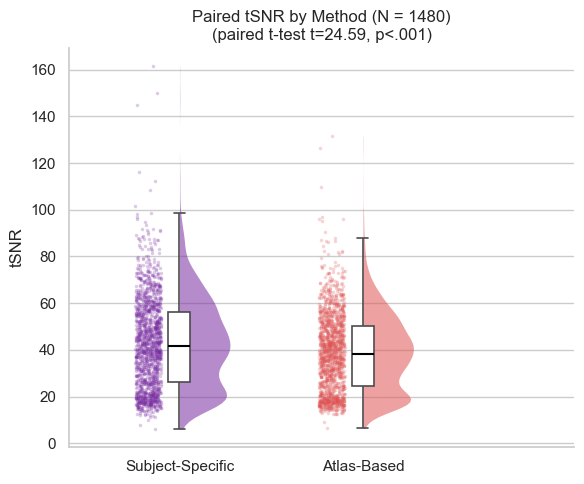

In [12]:
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")


def raincloud(ax, data, x, y, order, palette, width_viol=0.55, box_width=0.12,
              strip_size=2.5, strip_alpha=0.25, jitter=0.06, seed=0):
    """Paired raincloud plot: half-violin (cloud) + boxplot + jittered dots (rain)."""
    rng = np.random.default_rng(seed)
    sns.violinplot(
        data=data, x=x, y=y, order=order, hue=x, palette=palette,
        width=width_viol, inner=None, cut=0, linewidth=0, ax=ax,
        legend=False, density_norm="width", saturation=1,
    )
    # Clip each violin to its right half so it reads as a "cloud" beside the box/dots
    for i, coll in enumerate(ax.collections):
        for path in coll.get_paths():
            verts = path.vertices
            verts[:, 0] = np.clip(verts[:, 0], i, i + width_viol / 2 + 0.5)
        coll.set_alpha(0.55)

    sns.boxplot(
        data=data, x=x, y=y, order=order, width=box_width, showcaps=True,
        boxprops={"zorder": 3, "facecolor": "white", "linewidth": 1.2},
        whiskerprops={"zorder": 3, "linewidth": 1.2},
        medianprops={"color": "black", "zorder": 4, "linewidth": 1.5},
        capprops={"linewidth": 1.2}, fliersize=0, ax=ax,
    )

    # Individual participant dots, jittered to the left of the tick
    for i, cat in enumerate(order):
        vals = data.loc[data[x] == cat, y].to_numpy()
        x_jit = rng.uniform(-jitter - 0.18, -0.10, size=len(vals)) + i
        ax.scatter(x_jit, vals, s=strip_size ** 2, alpha=strip_alpha,
                   color=palette[cat], linewidths=0, zorder=2)

    ax.set_xlim(-0.6, len(order) - 1 + width_viol + 0.6)


# --- Paired raincloud plot (Subject-Specific vs. Atlas-Based tSNR) ---
# Combines a half-violin, boxplot, and individual participant dots to show how
# subject-specific ROIs reduce partial-volume noise relative to the atlas ROI
# (paired t-test reported in the title, computed in Section 3 above).
tsnr_long = pd.melt(
    df[["subject_id", "manual_tsnr", "atlas_tsnr"]],
    id_vars="subject_id", value_vars=["manual_tsnr", "atlas_tsnr"],
    var_name="Method", value_name="tSNR",
)
tsnr_long["Method"] = tsnr_long["Method"].map(
    {"manual_tsnr": "Subject-Specific", "atlas_tsnr": "Atlas-Based"}
)
tsnr_order = ["Subject-Specific", "Atlas-Based"]
tsnr_palette = {"Subject-Specific": "#792CA2", "Atlas-Based": "#E05454"}

fig, ax = plt.subplots(figsize=(6, 5))
raincloud(ax, tsnr_long, "Method", "tSNR", tsnr_order, tsnr_palette)
ax.set_xlabel("")
ax.set_ylabel("tSNR")
ax.set_title(f"Paired tSNR by Method (N = {len(df)})\n(paired t-test t={t_stat:.2f}, p<.001)")
sns.despine(ax=ax)
fig.tight_layout()

fig_path = op.join(roi_analysis_dir, "tsnr_raincloud_paired.png")
fig.savefig(fig_path, dpi=200, bbox_inches="tight")
print(f"Figure saved to: {fig_path}")
plt.show()


Figure saved to: ./dset/derivatives/roi-analysis/tsnr_bland_altman.png


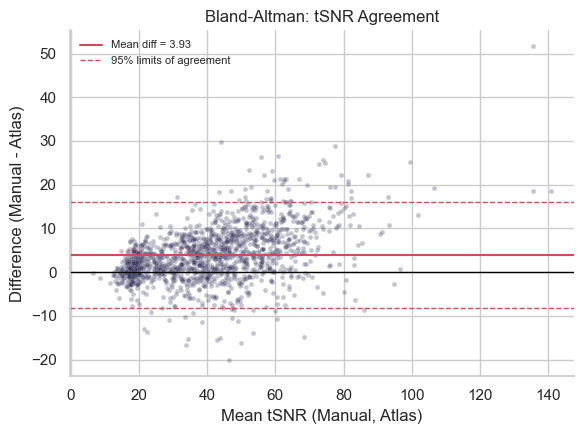

In [13]:
# --- Bland-Altman plot (mean of the two methods vs. their difference) ---
# Standard method-agreement plot - unlike the unity scatter, this puts the difference on its
# own axis against the pair's mean, which reveals whether the manual-atlas gap scales with
# overall signal level rather than being a flat offset. Relevant here given the wide spread
# in per-subject percent difference (-46.8% to 102.1%) found in Section 3.
tsnr_mean_pair = (df["manual_tsnr"] + df["atlas_tsnr"]) / 2
loa_upper = tsnr_diff.mean() + 1.96 * tsnr_diff.std()
loa_lower = tsnr_diff.mean() - 1.96 * tsnr_diff.std()

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.scatterplot(x=tsnr_mean_pair, y=tsnr_diff, alpha=0.25, s=12, color="#171744", ax=ax)
ax.axhline(tsnr_diff.mean(), color="#d1495b", linestyle="-", linewidth=1.5,
           label=f"Mean diff = {tsnr_diff.mean():.2f}")
ax.axhline(loa_upper, color="#d1495b", linestyle="--", linewidth=1,
           label="95% limits of agreement")
ax.axhline(loa_lower, color="#d1495b", linestyle="--", linewidth=1)
ax.axhline(0, color="black", linewidth=1)
ax.set_xlabel("Mean tSNR (Manual, Atlas)")
ax.set_ylabel("Difference (Manual - Atlas)")
ax.set_title("Bland-Altman: tSNR Agreement")
ax.legend(frameon=False, fontsize=8)
sns.despine(ax=ax)
fig.tight_layout()

fig_path = op.join(roi_analysis_dir, "tsnr_bland_altman.png")
fig.savefig(fig_path, dpi=200, bbox_inches="tight")
print(f"Figure saved to: {fig_path}")
plt.show()


Figure saved to: ./dset/derivatives/roi-analysis/tsnr_difference_histogram.png


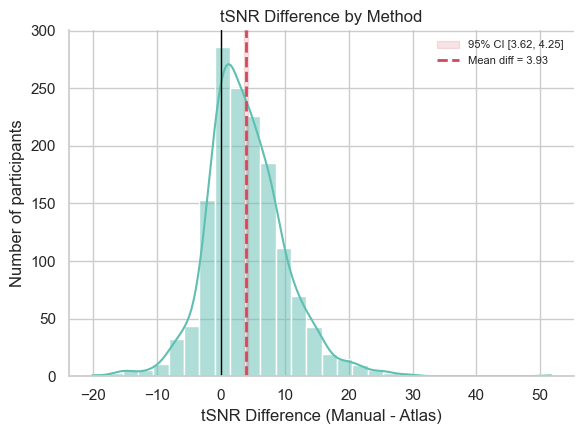

In [14]:
# --- tSNR difference distribution, with 95% CI band on the mean ---
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.histplot(tsnr_diff, bins=30, kde=True, color="#5fbfb1", edgecolor="white", ax=ax)
ax.axvline(0, color="black", linewidth=1)
ax.axvspan(diff_ci_low, diff_ci_high, color="#d1495b", alpha=0.15,
           label=f"95% CI [{diff_ci_low:.2f}, {diff_ci_high:.2f}]")
ax.axvline(tsnr_diff.mean(), color="#d1495b", linestyle="--", linewidth=2,
           label=f"Mean diff = {tsnr_diff.mean():.2f}")
ax.set_xlabel("tSNR Difference (Manual - Atlas)")
ax.set_ylabel("Number of participants")
ax.set_title("tSNR Difference by Method")
ax.legend(frameon=False, fontsize=8)
sns.despine(ax=ax)
fig.tight_layout()

fig_path = op.join(roi_analysis_dir, "tsnr_difference_histogram.png")
fig.savefig(fig_path, dpi=200, bbox_inches="tight")
print(f"Figure saved to: {fig_path}")
plt.show()


Figure saved to: ./dset/derivatives/roi-analysis/timeseries_correlation_histogram.png


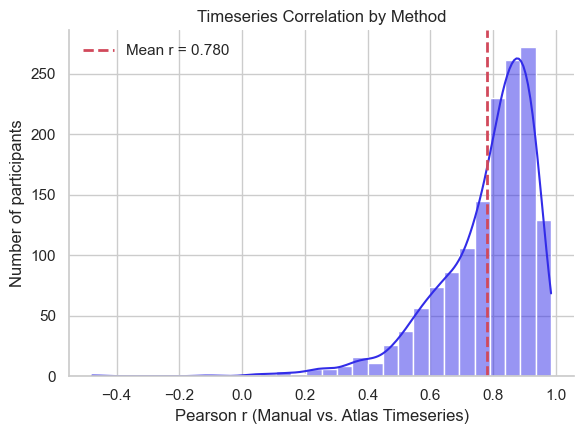

In [15]:
# --- Timeseries correlation distribution ---
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.histplot(r_series, bins=30, kde=True, color="#322ce8", edgecolor="white", ax=ax)
ax.axvline(r_series.mean(), color="#d1495b", linestyle="--", linewidth=2,
           label=f"Mean r = {r_series.mean():.3f}")
ax.set_xlabel("Pearson r (Manual vs. Atlas Timeseries)")
ax.set_ylabel("Number of participants")
ax.set_title("Timeseries Correlation by Method")
ax.legend(frameon=False)
sns.despine(ax=ax)
fig.tight_layout()

fig_path = op.join(roi_analysis_dir, "timeseries_correlation_histogram.png")
fig.savefig(fig_path, dpi=200, bbox_inches="tight")
print(f"Figure saved to: {fig_path}")
plt.show()


## 6. Notes for the Methods/Results Write-Up

- tSNR is significantly higher for the manual ROI than the atlas ROI (paired t-test and
  Wilcoxon both p < .001), though the mean difference is modest (~4 tSNR units). This makes
  sense directionally - the manual ROI is smaller and hand-placed to the habenula itself,
  while the atlas ROI is a larger, dilated region that likely includes more
  partial-volume/CSF-adjacent voxels, which would pull tSNR down slightly.
- Timeseries correlation between methods is high on average (mean r = 0.78, median = 0.83)
  but with real spread (range -0.48 to 0.98) - most participants show strong agreement
  between the two extraction methods, but a minority do not, which is worth flagging as a
  caveat rather than treating this as uniform equivalence.
- `sub-0050353` is excluded from the correlation analysis (empty manual-ROI timeseries) - see
  Section 2. Worth deciding whether to exclude this subject from the ROI/connectivity
  comparisons too, given the same underlying data issue likely affects those analyses.